In [16]:
"""
Challenge B — Quick exploration starter
Run this to see what the data looks like before building your solution.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bucket_access.bucket_utils import list_files, download_file

# ── 1. List available files ──────────────────────────────────────────────────
print("=== Files in challengeB/ ===")
for f in list_files("challengeB/"):
    print(" ", f)


=== Files in challengeB/ ===
  challengeB/
  challengeB/spatial_brain_maps/
  challengeB/spatial_brain_maps/atlas_regions.csv
  challengeB/spatial_brain_maps/brain_atlas_anatomy.nii.gz
  challengeB/spatial_brain_maps/brain_atlas_regions.nii.gz
  challengeB/spatial_brain_maps/cfos_G001_median.nii.gz
  challengeB/spatial_brain_maps/cfos_G002_median.nii.gz
  challengeB/spatial_brain_maps/cfos_group_median_difference_G002_vs_G001.nii.gz
  challengeB/tabular_data_quantification/
  challengeB/tabular_data_quantification/cfos_object_density_quantification.csv
  challengeB/tabular_data_quantification/cfos_object_density_statistics_G002_vs_G001.csv


In [17]:

# ── 2. Download tabular data ─────────────────────────────────────────────────
os.makedirs("data_b", exist_ok=True)
print("\nDownloading tabular data...")
download_file(
    "challengeB/tabular_data_quantification/cfos_object_density_quantification.csv",
    "data_b/quantification.csv"
)
download_file(
    "challengeB/tabular_data_quantification/cfos_object_density_statistics_G002_vs_G001.csv",
    "data_b/statistics.csv"
)

# ── 3. Load and explore ───────────────────────────────────────────────────────
quant = pd.read_csv("data_b/quantification.csv")
stats = pd.read_csv("data_b/statistics.csv")

print(f"\n=== Quantification data ===")
print(f"  Shape: {quant.shape}  ({quant['group_nr'].value_counts().to_dict()})")
print(quant[["scan_name", "animal_nr", "group_nr"]].head(6).to_string(index=False))

print(f"\n=== Statistics data ===")
print(f"  Shape: {stats.shape}")
print(f"  Columns: {list(stats.columns)}")
sig_corrected = stats[stats["significant_corrected"] == True].shape[0]
sig_uncorrected = stats[stats["significant_uncorrected"] == True].shape[0]
print(f"\n  Significant (corrected p<0.05):   {sig_corrected} regions")
print(f"  Significant (uncorrected p<0.05): {sig_uncorrected} regions")



✓ Downloaded → data_b/quantification.csv
✓ Downloaded → data_b/statistics.csv

=== Quantification data ===
  Shape: (12, 1359)  ({'G002': 6, 'G001': 6})
                                       scan_name animal_nr group_nr
260219_AN0B2_G002_mouse_brain_MB1_SCAN0_11-56-32     AN0B2     G002
260219_AN0B4_G002_mouse_brain_MB1_SCAN0_14-05-25     AN0B4     G002
260219_AN0B7_G002_mouse_brain_MB1_SCAN0_16-11-05     AN0B7     G002
260220_AN0A4_G001_mouse_brain_MB1_SCAN0_13-28-02     AN0A4     G001
260223_AN0A7_G001_mouse_brain_MB1_SCAN0_10-31-31     AN0A7     G001
260224_AN0A2_G001_mouse_brain_MB1_SCAN0_09-09-05     AN0A2     G001

=== Statistics data ===
  Shape: (1356, 28)
  Columns: ['region_id', 'region_name', 'acronym', 'hierarchy_level', 'is_lowest_level', 'n_A', 'n_B', 'n_A_eff', 'n_B_eff', 'mean_A', 'mean_B', 'median_A', 'median_B', 'std_A', 'std_B', 'sem_A', 'sem_B', 'mean_diff', 'ci_low', 'ci_high', 'fold_change', 'log2_fold_change', 'log2fc_ci_low', 'log2fc_ci_high', 'p_value', 'p_co

In [18]:

# ── 4. Top differentially activated regions ───────────────────────────────────
print("\n=== Top 10 UPREGULATED in Semaglutide (G002) ===")
up = stats.nlargest(10, "log2_fold_change")[
    ["acronym", "region_name", "log2_fold_change", "p_corrected", "significant_corrected"]
]
print(up.to_string(index=False))

print("\n=== Top 10 DOWNREGULATED in Semaglutide (G002) ===")
down = stats.nsmallest(10, "log2_fold_change")[
    ["acronym", "region_name", "log2_fold_change", "p_corrected", "significant_corrected"]
]
print(down.to_string(index=False))



=== Top 10 UPREGULATED in Semaglutide (G002) ===
acronym                              region_name  log2_fold_change  p_corrected  significant_corrected
    NTS            Nucleus of the solitary tract          2.767218     0.499750                    0.0
   dscp superior cerebellar peduncle decussation          2.519495     1.000000                    0.0
    INC            Interstitial nucleus of Cajal          2.176332     0.890194                    0.0
    MEV              Midbrain trigeminal nucleus          2.167492     0.818594                    0.0
    III                       Oculomotor nucleus          2.136428     1.000000                    0.0
    DMX  Dorsal motor nucleus of the vagus nerve          2.039545     0.504850                    0.0
     MD          Mediodorsal nucleus of thalamus          1.955321     0.493376                    0.0
     Xn                              vagus nerve          1.884917          NaN                    NaN
     ts                


Generating volcano plot...
  Saved: challenge_b_volcano.png


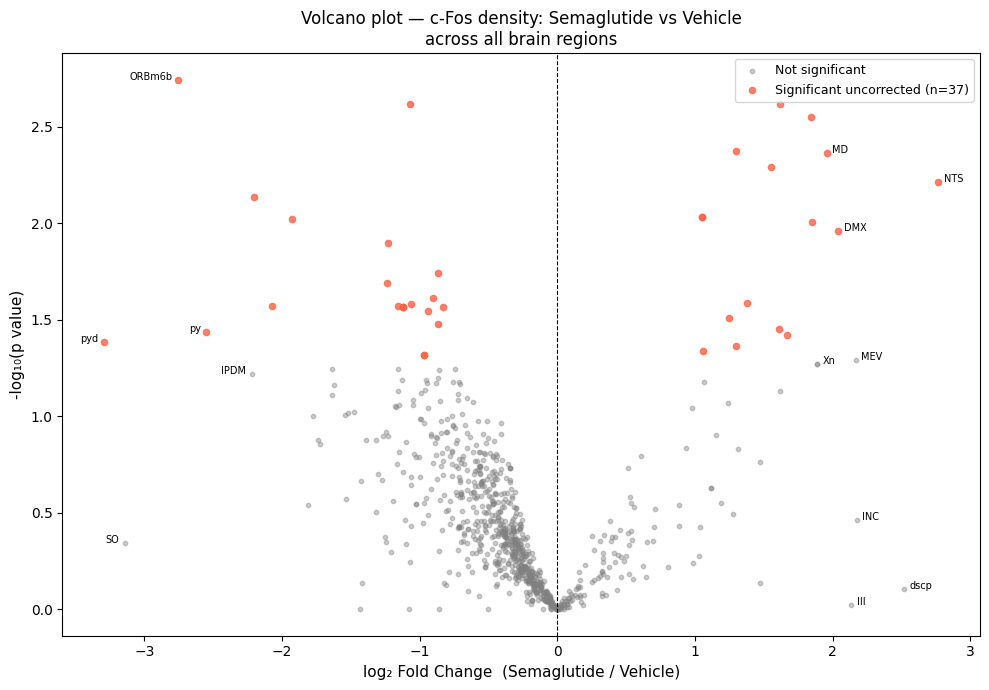

In [19]:
# ── 5. Volcano plot ───────────────────────────────────────────────────────────
print("\nGenerating volcano plot...")

fig, ax = plt.subplots(figsize=(10, 7))

# colour by uncorrected significance (no regions survive corrected p<0.05)
not_sig = stats[stats["significant_uncorrected"] != True]
sig = stats[stats["significant_uncorrected"] == True]

ax.scatter(not_sig["log2_fold_change"], -np.log10(not_sig["p_value"]),
           s=10, alpha=0.4, color="grey", label="Not significant")
ax.scatter(sig["log2_fold_change"], -np.log10(sig["p_value"]),
           s=20, alpha=0.8, color="tomato", label=f"Significant uncorrected (n={len(sig)})")

# label top hits
for _, row in stats.nlargest(8, "log2_fold_change").iterrows():
    ax.annotate(row["acronym"], (row["log2_fold_change"], -np.log10(row["p_value"])),
                fontsize=7, ha="left", xytext=(4, 0), textcoords="offset points")
for _, row in stats.nsmallest(5, "log2_fold_change").iterrows():
    ax.annotate(row["acronym"], (row["log2_fold_change"], -np.log10(row["p_value"])),
                fontsize=7, ha="right", xytext=(-4, 0), textcoords="offset points")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("log₂ Fold Change  (Semaglutide / Vehicle)", fontsize=11)
ax.set_ylabel("-log₁₀(p value)", fontsize=11)
ax.set_title("Volcano plot — c-Fos density: Semaglutide vs Vehicle\nacross all brain regions", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("challenge_b_volcano.png", dpi=130)
print("  Saved: challenge_b_volcano.png")

Based on the data we already loaded, here's what the plot is showing:

X-axis (log2 fold change): How much more or less c-Fos (neuronal activity) there is in Semaglutide mice vs control. Positive = more active in Semaglutide, negative = less active.

Y-axis (-log10 p-value): Statistical confidence. Higher up = more significant.

What the pattern means:

Most brain regions (grey) show no meaningful difference — Semaglutide doesn't broadly rewire the brain
The 37 red dots are scattered across both sides — the drug both activates and suppresses specific regions
The strongest upregulated hit is NTS (Nucleus of the solitary tract, log2FC=2.77), alongside DMX (Dorsal motor nucleus of the vagus nerve) — these are exactly the brainstem regions involved in hunger suppression and gut-brain signaling, which is precisely how Ozempic is thought to work
The strongest downregulated hit is SO (Supraoptic nucleus, log2FC=-3.14), which regulates fluid balance and stress hormones
The biological story: The drug is specifically activating the vagus nerve/brainstem circuit that signals fullness and suppressing hypothalamic regions — consistent with the known mechanism of GLP-1 agonists reducing appetite. That's a genuinely interesting result to present.

  Saved: challenge_b_top_regions.png


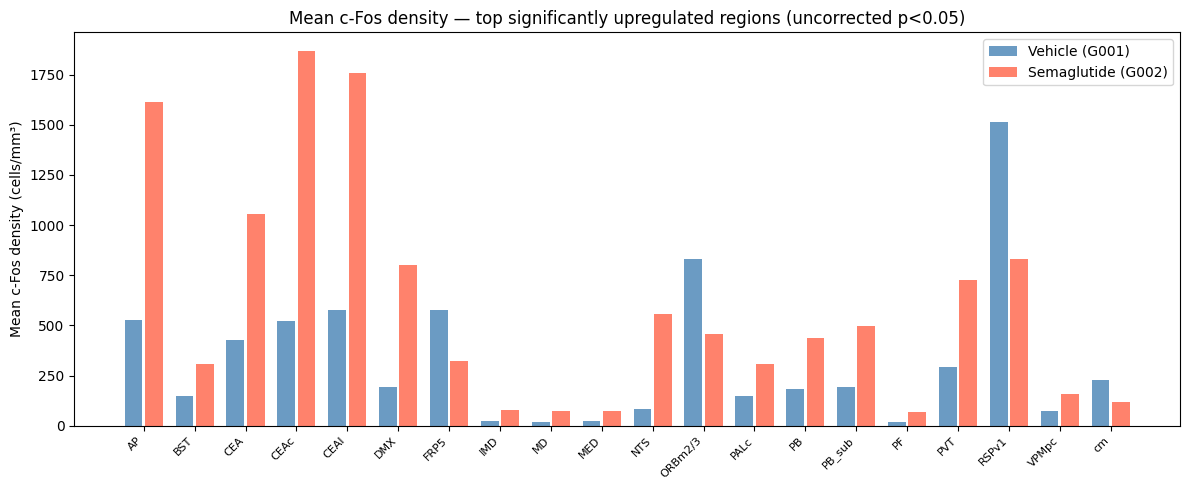

In [20]:
# ── 6. Distribution of c-Fos by region (top 20 uncorrected significant regions) ──────────
top_regions = stats[stats["significant_uncorrected"] == True].nlargest(20, "log2_fold_change")["acronym"].tolist()
region_cols = [c for c in quant.columns if c in top_regions]

if region_cols:
    long_df = quant.melt(
        id_vars=["group_nr"], value_vars=region_cols,
        var_name="region", value_name="density"
    )
    g001 = long_df[long_df["group_nr"] == "G001"].groupby("region")["density"].mean()
    g002 = long_df[long_df["group_nr"] == "G002"].groupby("region")["density"].mean()
    merged = pd.DataFrame({"Vehicle (G001)": g001, "Semaglutide (G002)": g002}).dropna()
    merged = merged.loc[merged.index.isin(region_cols)]

    fig2, ax2 = plt.subplots(figsize=(12, 5))
    x = np.arange(len(merged))
    ax2.bar(x - 0.2, merged["Vehicle (G001)"], 0.35, label="Vehicle (G001)", color="steelblue", alpha=0.8)
    ax2.bar(x + 0.2, merged["Semaglutide (G002)"], 0.35, label="Semaglutide (G002)", color="tomato", alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(merged.index, rotation=45, ha="right", fontsize=8)
    ax2.set_ylabel("Mean c-Fos density (cells/mm³)")
    ax2.set_title("Mean c-Fos density — top significantly upregulated regions (uncorrected p<0.05)")
    ax2.legend()
    plt.tight_layout()
    plt.savefig("challenge_b_top_regions.png", dpi=130)
    print("  Saved: challenge_b_top_regions.png")
else:
    print("  No matching region columns found in quantification data")

In [21]:

print("\nDone! Open challenge_b_volcano.png to see the full picture.")
print("\nNext steps for Challenge B:")
print("  1. Run `python challenge_b_agent.py` to chat with Claude about the data")
print("  2. Build a Streamlit/Dash dashboard using the volcano + bar plots above")
print("  3. Add NIfTI spatial brain maps for the coolest visual extension")



Done! Open challenge_b_volcano.png to see the full picture.

Next steps for Challenge B:
  1. Run `python challenge_b_agent.py` to chat with Claude about the data
  2. Build a Streamlit/Dash dashboard using the volcano + bar plots above
  3. Add NIfTI spatial brain maps for the coolest visual extension
